In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


AKILLI TELEFON BAĞIMLILIĞINI TAHMIN ETME-EDA Chris Deotte (kaggle grandmaster) yol harıtası ile  ile :

Bu, Kaggle'ın **Playground Series - Season 6, Episode 8** yarışması *Predicting Smartphone Addiction (Akıllı Telefon Bağımlılığını Tahmin Etme)* için hazırlanmış bir EDA (keşifsel veri analizi) notebook'udur.

> **Atıf / Reference:** Bu analiz, Kaggle Grandmaster [Chris Deotte](https://www.kaggle.com/cdeotte)'nin tablosal EDA yol haritası temel alınarak Türkçe'ye çevrilmiş ve uyarlanmıştır.

Temel tablosal EDA ile aynı basit iş akışını izliyor:
* her sütun kategorik mi yoksa sayısal mı?
* kaç tane benzersiz değer var?
* kaç tane eksik değer var?
* her özelliğin dağılımı neye benziyor?
* her özellik hedef değişkenle nasıl ilişkili?
* hedef değişkenin dağılımı neye benziyor?

Sonra, bu veri setinin ilginç bir yapısı olduğu için birkaç ekstra keşif ekliyoruz:
* 🕵️ **Eksiklik dedektifliği** — bir değerin eksik olması, tek başına bir şey söylüyor mu?
* 🧗 **Ekran süresi uçurumu** — bağımlılık oranı nerede aniden sıçrıyor?
* 🔥 **Etkileşim ısı haritaları (heatmap)** — özellik kombinasyonları tek başına özelliklerden daha mı önemli?
* 🧪 **Feature engineering oyun alanı** — basit oranlar/artıklar gizli bir yapıyı ortaya çıkarabilir mi?
* 🧭 **ID mantık kontrolü** — sentetik veri, satır sırasına göre kayma (drift) gösteriyor mu?

> Yarışma, `addicted_label` hedefiyle ikili sınıflandırma (binary classification) problemidir ve ROC AUC ile değerlendirilir. Notebook kasıtlı olarak EDA odaklıdır: model eğitimi yoktur, sadece bir sonraki adımda ne denenmesi gerektiğine dair ipuçları vardır.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

# Ufak bir cila. Temel notebook'taki tanıdık mavi/turuncu EDA renklerini koruyoruz.
BAR_COLOR = "tab:blue"
LINE_COLOR = "tab:orange"
ACCENT_COLOR = "tab:purple"
GOOD_COLOR = "tab:green"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

candidate_paths = [
    Path("/kaggle/input/playground-series-s6e8/train.csv"),
    Path("/kaggle/input/competitions/playground-series-s6e8/train.csv"),
    Path("/mnt/data/train_s6e8.csv"),
    Path("train.csv"),
]

TRAIN_PATH = next((p for p in candidate_paths if p.exists()), None)
if TRAIN_PATH is None:
    raise FileNotFoundError(
        "train.csv bulunamadı. Kaggle üzerinde, önce yarışma verisini notebook'a ekleyin."
    )

train = pd.read_csv(TRAIN_PATH)
TARGET = "addicted_label"
ID_COL = "id"
FEATURES = [c for c in train.columns if c not in [ID_COL, TARGET]]

print(f"Yüklendi: {TRAIN_PATH}")
print(f"Eğitim verisi boyutu: {train.shape[0]:,} satır × {train.shape[1]} sütun")
print(f"Özellik sayısı: {len(FEATURES)}")
display(train.head())


Yüklendi: /kaggle/input/competitions/playground-series-s6e8/train.csv
Eğitim verisi boyutu: 691,369 satır × 14 sütun
Özellik sayısı: 12


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.000,NaN,1.830,1.590,2.110,7.460,122.000,38.000,8.630,Male,Medium,No,1
1,1,19.000,5.970,1.080,NaN,3.030,8.220,76.000,19.000,NaN,Female,Medium,No,0
2,2,18.000,5.090,NaN,NaN,NaN,6.250,134.000,60.000,7.470,Female,Low,Yes,0
3,3,21.000,6.420,1.260,1.420,3.360,8.850,112.000,94.000,8.660,Other,Low,NaN,1
4,4,26.000,11.200,1.870,2.810,1.950,5.250,NaN,NaN,13.390,Female,Medium,No,1


 2. Kadroyla Tanışalım 🎭

Herhangi bir grafik çizmeden önce, sıkıcı ama önemli olan gerçekleri halledelim. Bu tablo, orijinal temel EDA'daki aynı soruları tek ve derli toplu bir görünümde cevaplıyor.


In [3]:
def feature_overview(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    rows = []
    for col in features:
        rows.append({
            "feature": col,
            "dtype": str(df[col].dtype),
            "unique": df[col].nunique(dropna=True),
            "missing": df[col].isna().sum(),
            "missing_%": 100 * df[col].isna().mean(),
            "example": df[col].dropna().iloc[0] if df[col].notna().any() else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["dtype", "unique"]).reset_index(drop=True)

overview = feature_overview(train, FEATURES)
display(overview.style.background_gradient(subset=["missing_%"], cmap="Blues").format({"missing_%": "{:.2f}%"}))

print(f"Hedef ortalaması: {train[TARGET].mean():.4f}")
print(f"Her özellikte eksik değer var mı: {bool((overview['missing'] > 0).all())}")


,feature,dtype,unique,missing,missing_%,example
0,age,float64,18,28929,4.18%,24.000000
1,app_opens_per_day,float64,166,80710,11.67%,38.000000
2,notifications_per_day,float64,231,67584,9.78%,122.000000
3,gaming_hours,float64,401,126821,18.34%,1.590000
4,sleep_hours,float64,451,44480,6.43%,7.460000
5,work_study_hours,float64,600,51518,7.45%,2.110000
6,social_media_hours,float64,721,133995,19.38%,1.830000
7,daily_screen_time_hours,float64,1389,95854,13.86%,5.970000
8,weekend_screen_time,float64,1437,112063,16.21%,8.630000
9,academic_work_impact,object,2,44224,6.40%,No


Hedef ortalaması: 0.7094
Her özellikte eksik değer var mı: True


 3. Temel EDA Fonksiyonu 🔭

 aşağıdaki yardımcı fonksiyon **özellik sıklığını** (barlar) **ortalama hedef değeriyle** (turuncu çizgi) üst üste bindiriyor. Bu yarışma için ortalama hedef özellikle sezgisel: basitçe `addicted_label = 1` olan satırların oranı.

Küçük bir iyileştirme: kategorik özelliklerde eksik değerler kendi kategorisi olarak gösteriliyor, sayısal grafiklerde ise eksik sayısı başlıkta raporlanıyor.


In [4]:
def plot_features_dual_axis(
    df: pd.DataFrame,
    cols: list[str],
    target_col: str,
    n_bins: int = 10,
    n_wide: int = 3,
    figsize_per_plot: tuple[float, float] = (5.2, 4.2),
    int_as_cat_unique_max: int | None = 20,
    cat_order: dict[str, list] | None = None,
):
    def is_categorical(s: pd.Series) -> bool:
        return (
            s.dtype == "object"
            or pd.api.types.is_string_dtype(s)
            or isinstance(s.dtype, pd.CategoricalDtype)
        )

    n_cols = len(cols)
    n_rows = int(np.ceil(n_cols / n_wide))
    fig, axes = plt.subplots(
        n_rows,
        n_wide,
        figsize=(figsize_per_plot[0] * n_wide, figsize_per_plot[1] * n_rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax1 = axes[i]
        n_nan = int(df[col].isna().sum())
        n_unique = int(df[col].nunique(dropna=True))
        s = df[col]

        # ---------- GERÇEK KATEGORİK ----------
        if is_categorical(s):
            type_str = "kategorik"
            tmp = df[[col, target_col]].copy()
            tmp[col] = tmp[col].astype("object").where(tmp[col].notna(), "(eksik)")

            counts = tmp[col].value_counts()
            mean_y = tmp.groupby(col, dropna=False)[target_col].mean()

            if cat_order is not None and col in cat_order:
                desired = list(cat_order[col])
                ordered = [c for c in desired if c in counts.index]
                remaining = [c for c in counts.index if c not in ordered]
                final_order = ordered + sorted(remaining, key=str)
            else:
                final_order = sorted(counts.index, key=str)

            counts = counts.reindex(final_order)
            mean_y = mean_y.reindex(final_order)
            xpos = np.arange(len(final_order))

            ax1.bar(xpos, counts.values, alpha=0.60, color=BAR_COLOR)
            ax1.set_ylabel("Sayım", color=BAR_COLOR)
            ax1.tick_params(axis="y", colors=BAR_COLOR)
            ax1.set_xticks(xpos)
            ax1.set_xticklabels(final_order, rotation=35, ha="right")

            ax2 = ax1.twinx()
            ax2.plot(xpos, mean_y.values, marker="o", color=LINE_COLOR, linewidth=2)
            ax2.axhline(df[target_col].mean(), color="0.4", linestyle="--", linewidth=1, alpha=0.7)
            ax2.set_ylabel(f"Ortalama {target_col}", color=LINE_COLOR)
            ax2.tick_params(axis="y", colors=LINE_COLOR)
            ax2.set_ylim(0, 1)

            ax1.set_title(
                f"{col}: Sayım vs Ortalama {target_col}\n"
                f"({type_str}, {n_unique} benzersiz, {n_nan:,} eksik)"
            )

        # ---------- SAYISAL ----------
        else:
            type_str = "sayısal"
            tmp = df[[col, target_col]].dropna()
            xvals = tmp[col].to_numpy()
            yvals = tmp[target_col].to_numpy()
            finite = np.isfinite(xvals) & np.isfinite(yvals)
            xvals, yvals = xvals[finite], yvals[finite]

            if len(xvals) == 0:
                ax1.set_title(f"{col} — dropna sonrası boş")
                continue

            unique_vals = np.sort(np.unique(xvals))
            n_unique_eff = len(unique_vals)

            if int_as_cat_unique_max is not None and n_unique_eff <= int_as_cat_unique_max:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])
                xpos = np.arange(n_unique_eff)

                ax1.bar(xpos, counts, alpha=0.60, color=BAR_COLOR)
                ax1.set_ylabel("Sayım", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)
                step = max(int(np.ceil(n_unique_eff / 10)), 1)
                tick_idx = np.arange(0, n_unique_eff, step)
                ax1.set_xticks(tick_idx)
                ax1.set_xticklabels([f"{v:g}" for v in unique_vals[tick_idx]], rotation=35, ha="right")

                ax2 = ax1.twinx()
                ax2.plot(xpos, mean_y, marker="o", color=LINE_COLOR, linewidth=2)
                ax2.axhline(df[target_col].mean(), color="0.4", linestyle="--", linewidth=1, alpha=0.7)
                ax2.set_ylim(0, 1)
                ax2.set_ylabel(f"Ortalama {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

            else:
                bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
                # en sağdaki sınırı güvenle dahil et
                bin_idx = np.clip(np.digitize(xvals, bins, right=False) - 1, 0, n_bins - 1)
                counts = np.bincount(bin_idx, minlength=n_bins)
                mean_y = np.array([
                    yvals[bin_idx == j].mean() if np.any(bin_idx == j) else np.nan
                    for j in range(n_bins)
                ])
                centers = 0.5 * (bins[:-1] + bins[1:])
                width = (bins[1] - bins[0]) * 0.92

                ax1.bar(centers, counts, width=width, alpha=0.60, color=BAR_COLOR)
                ax1.set_ylabel("Sayım", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(centers, mean_y, marker="o", color=LINE_COLOR, linewidth=2)
                ax2.axhline(df[target_col].mean(), color="0.4", linestyle="--", linewidth=1, alpha=0.7)
                ax2.set_ylim(0, 1)
                ax2.set_ylabel(f"Ortalama {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

            ax1.set_xlabel(col)
            ax1.set_title(
                f"{col}: Dağılım vs Ortalama {target_col}\n"
                f"({type_str}, {n_unique} benzersiz, {n_nan:,} eksik)"
            )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    


4. Özellik EDA'sını Göster 📊

Aşağıdaki her özellik için:
* **mavi barlar** = değerin/aralığın (bin) ne kadar yaygın olduğu
* **turuncu çizgi** = o değerdeki/aralıktaki bağımlılık oranı
* **gri kesikli çizgi** = genel (ortalama) bağımlılık oranı

Turuncu çizgi, kesikli temel çizgiden ne kadar çok saparsa, o özellik o kadar fazla bağımsız (standalone) sinyal içeriyor olabilir.


12 adet model özelliği var:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']


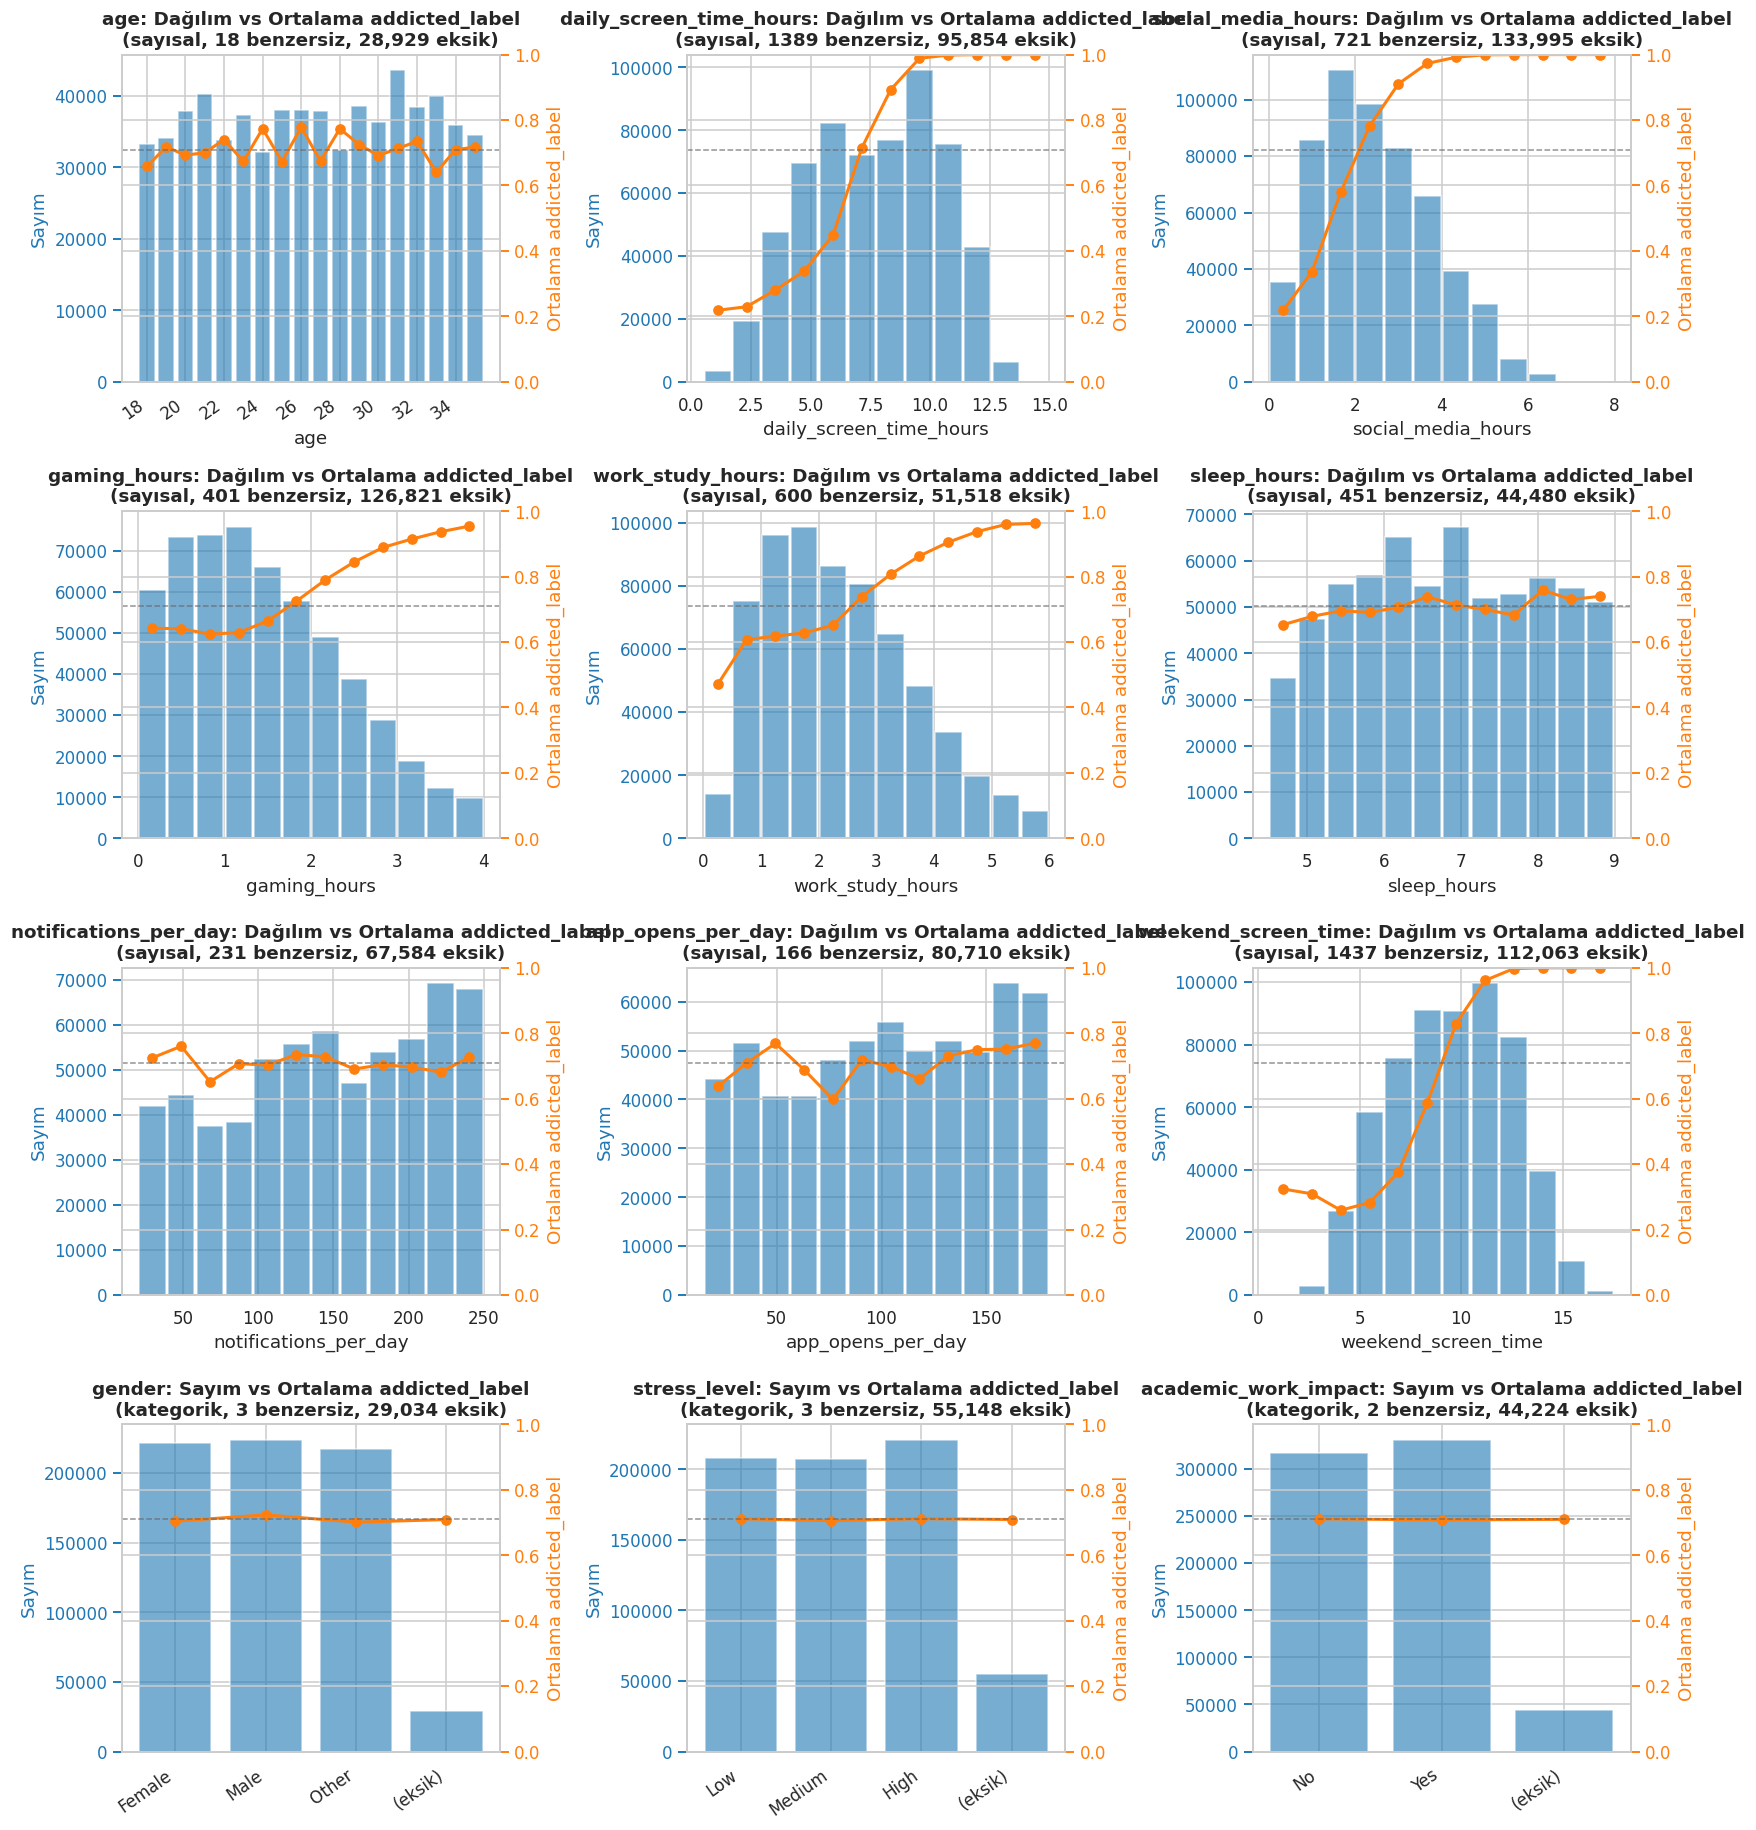

In [5]:
CAT_ORDER = {
    "gender": ["Female", "Male", "Other", "(missing)"],
    "stress_level": ["Low", "Medium", "High", "(missing)"],
    "academic_work_impact": ["No", "Yes", "(missing)"],
}

print(f"{len(FEATURES)} adet model özelliği var:")
print(FEATURES)

plot_features_dual_axis(
    train,
    cols=FEATURES,
    target_col=TARGET,
    n_bins=12,
    n_wide=3,
    int_as_cat_unique_max=20,
    cat_order=CAT_ORDER,
)


5. Hedef Değişken EDA'sını Göster 🎯

ROC AUC, pozitif örnekleri negatiflerin üzerinde sıralamaya önem verir, bu yüzden sınıf dengesi yarışma skorunu doğrudan belirlemez. Yine de bu sentetik popülasyonda "normal"in ne olduğunu bize gösterir.


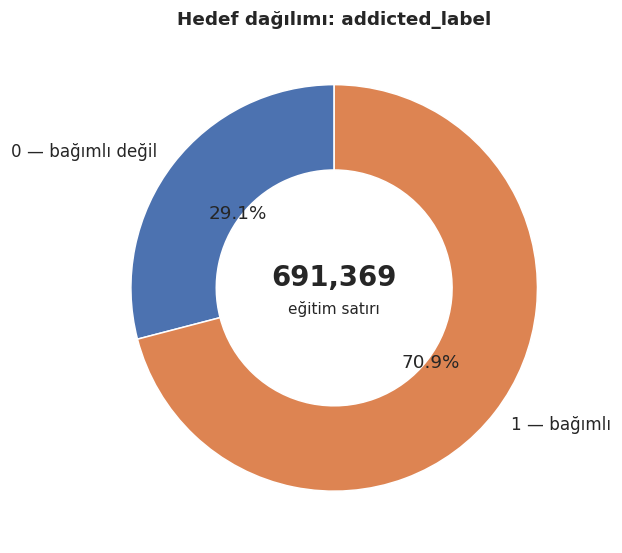

Pozitif sınıf oranı: 70.94%


In [6]:
counts = train[TARGET].value_counts().sort_index()
labels = ["0 — bağımlı değil", "1 — bağımlı"]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
)
ax.text(0, 0.05, f"{len(train):,}", ha="center", va="center", fontsize=18, fontweight="bold")
ax.text(0, -0.10, "eğitim satırı", ha="center", va="center", fontsize=10)
ax.set_title("Hedef dağılımı: addicted_label")
plt.show()

print(f"Pozitif sınıf oranı: {train[TARGET].mean():.2%}")


6. Eksiklik Dedektif Panosu 🕵️‍♀️

Her bir tahmin edici (predictor) değişkende eksik değer var. İki ayrı soru önemli:

1. **Her özellik ne sıklıkla eksik?**
2. **"Bu değer eksik" olması, tek başına hedef değişkenle ilişkili mi?**

Eğer eksiklik, hedef oranını güçlü şekilde değiştiriyorsa, açık "eksik göstergesi (missing indicator)" değişkenleri eklemek faydalı olabilir. Etki küçükse, model muhtemelen eksiklik bayrakları yerine iyi bir işleme/imputation stratejisine ihtiyaç duyar.


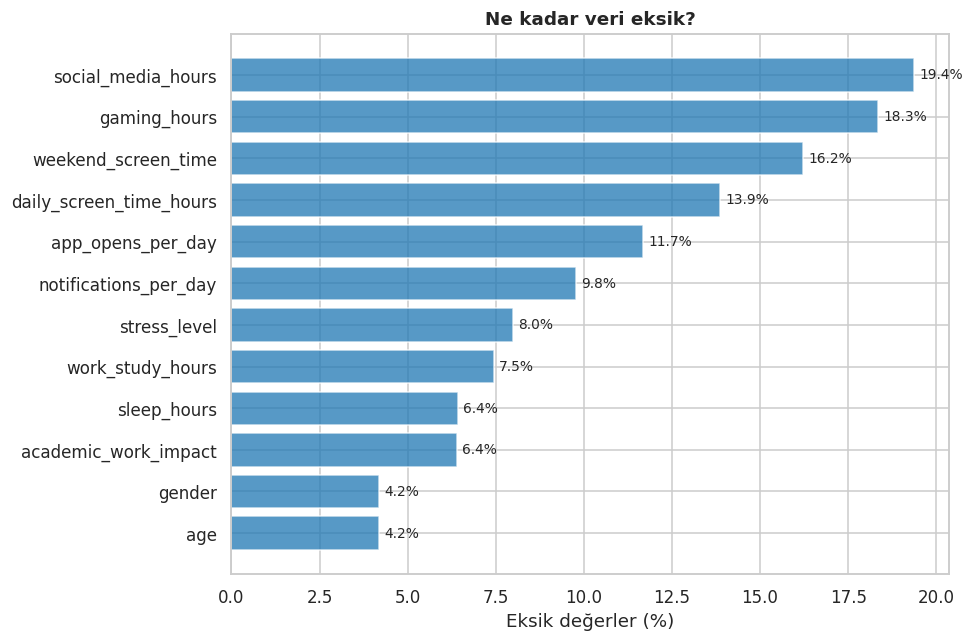

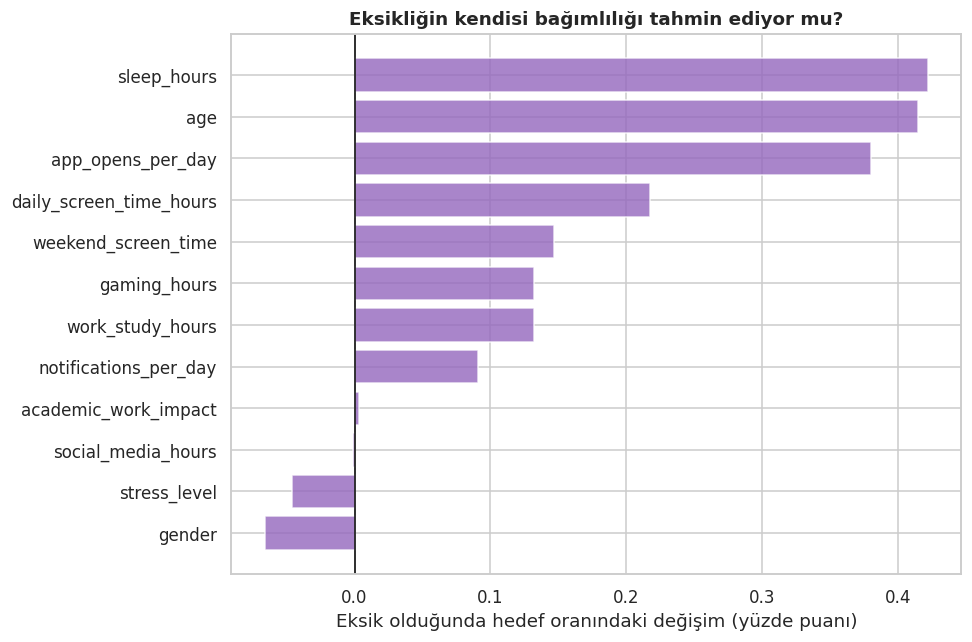

,feature,missing_%,target_if_missing,target_if_present,delta_pp
5,sleep_hours,6.43%,0.713,0.709,+0.422 pp
0,age,4.18%,0.713,0.709,+0.415 pp
7,app_opens_per_day,11.67%,0.713,0.709,+0.381 pp
1,daily_screen_time_hours,13.86%,0.711,0.709,+0.218 pp
8,weekend_screen_time,16.21%,0.711,0.709,+0.147 pp
3,gaming_hours,18.34%,0.711,0.709,+0.132 pp
4,work_study_hours,7.45%,0.711,0.709,+0.132 pp
6,notifications_per_day,9.78%,0.710,0.709,+0.091 pp
9,gender,4.20%,0.709,0.709,-0.066 pp
10,stress_level,7.98%,0.709,0.709,-0.046 pp


In [7]:
missing_rows = []
for col in FEATURES:
    is_missing = train[col].isna()
    missing_rows.append({
        "feature": col,
        "missing_%": 100 * is_missing.mean(),
        "target_if_missing": train.loc[is_missing, TARGET].mean(),
        "target_if_present": train.loc[~is_missing, TARGET].mean(),
    })

missing_df = pd.DataFrame(missing_rows)
missing_df["delta_pp"] = 100 * (missing_df["target_if_missing"] - missing_df["target_if_present"])
missing_df = missing_df.sort_values("missing_%", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(missing_df["feature"], missing_df["missing_%"], alpha=0.75, color=BAR_COLOR)
ax.set_xlabel("Eksik değerler (%)")
ax.set_title("Ne kadar veri eksik?")
for y, v in enumerate(missing_df["missing_%"]):
    ax.text(v + 0.15, y, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

signal = missing_df.sort_values("delta_pp")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(signal["feature"], signal["delta_pp"], alpha=0.80, color=ACCENT_COLOR)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Eksik olduğunda hedef oranındaki değişim (yüzde puanı)")
ax.set_title("Eksikliğin kendisi bağımlılığı tahmin ediyor mu?")
plt.tight_layout()
plt.show()

display(signal[["feature", "missing_%", "target_if_missing", "target_if_present", "delta_pp"]]
        .sort_values("delta_pp", key=lambda s: s.abs(), ascending=False)
        .style.format({
            "missing_%": "{:.2f}%",
            "target_if_missing": "{:.3f}",
            "target_if_present": "{:.3f}",
            "delta_pp": "{:+.3f} pp",
        }))


7. Ekran Süresi Uçurumu 🧗📱

Histogramlar doğrusal olmayan sıçramaları gizleyebilir. Burada her sayısal özelliği **10 eşit-frekanslı gruba (decile)** bölüyoruz ve tek bir basit soru soruyoruz:

> En düşük riskli decile'dan en yüksek riskli decile'a kadar bağımlılık oranı ne kadar hareket edebiliyor?

Bu, özellikleri sadece Pearson korelasyonuna göre değil, **şekillerine** göre hızlıca sıralamanın bir yolu.


,feature,min_rate,max_rate,range_pp
2,social_media_hours,0.250,0.999,74.9 pp
8,weekend_screen_time,0.264,1.000,73.5 pp
1,daily_screen_time_hours,0.265,1.000,73.5 pp
4,work_study_hours,0.581,0.936,35.5 pp
3,gaming_hours,0.613,0.922,30.9 pp
7,app_opens_per_day,0.645,0.770,12.5 pp
5,sleep_hours,0.657,0.735,7.8 pp
0,age,0.673,0.747,7.4 pp
6,notifications_per_day,0.670,0.733,6.3 pp


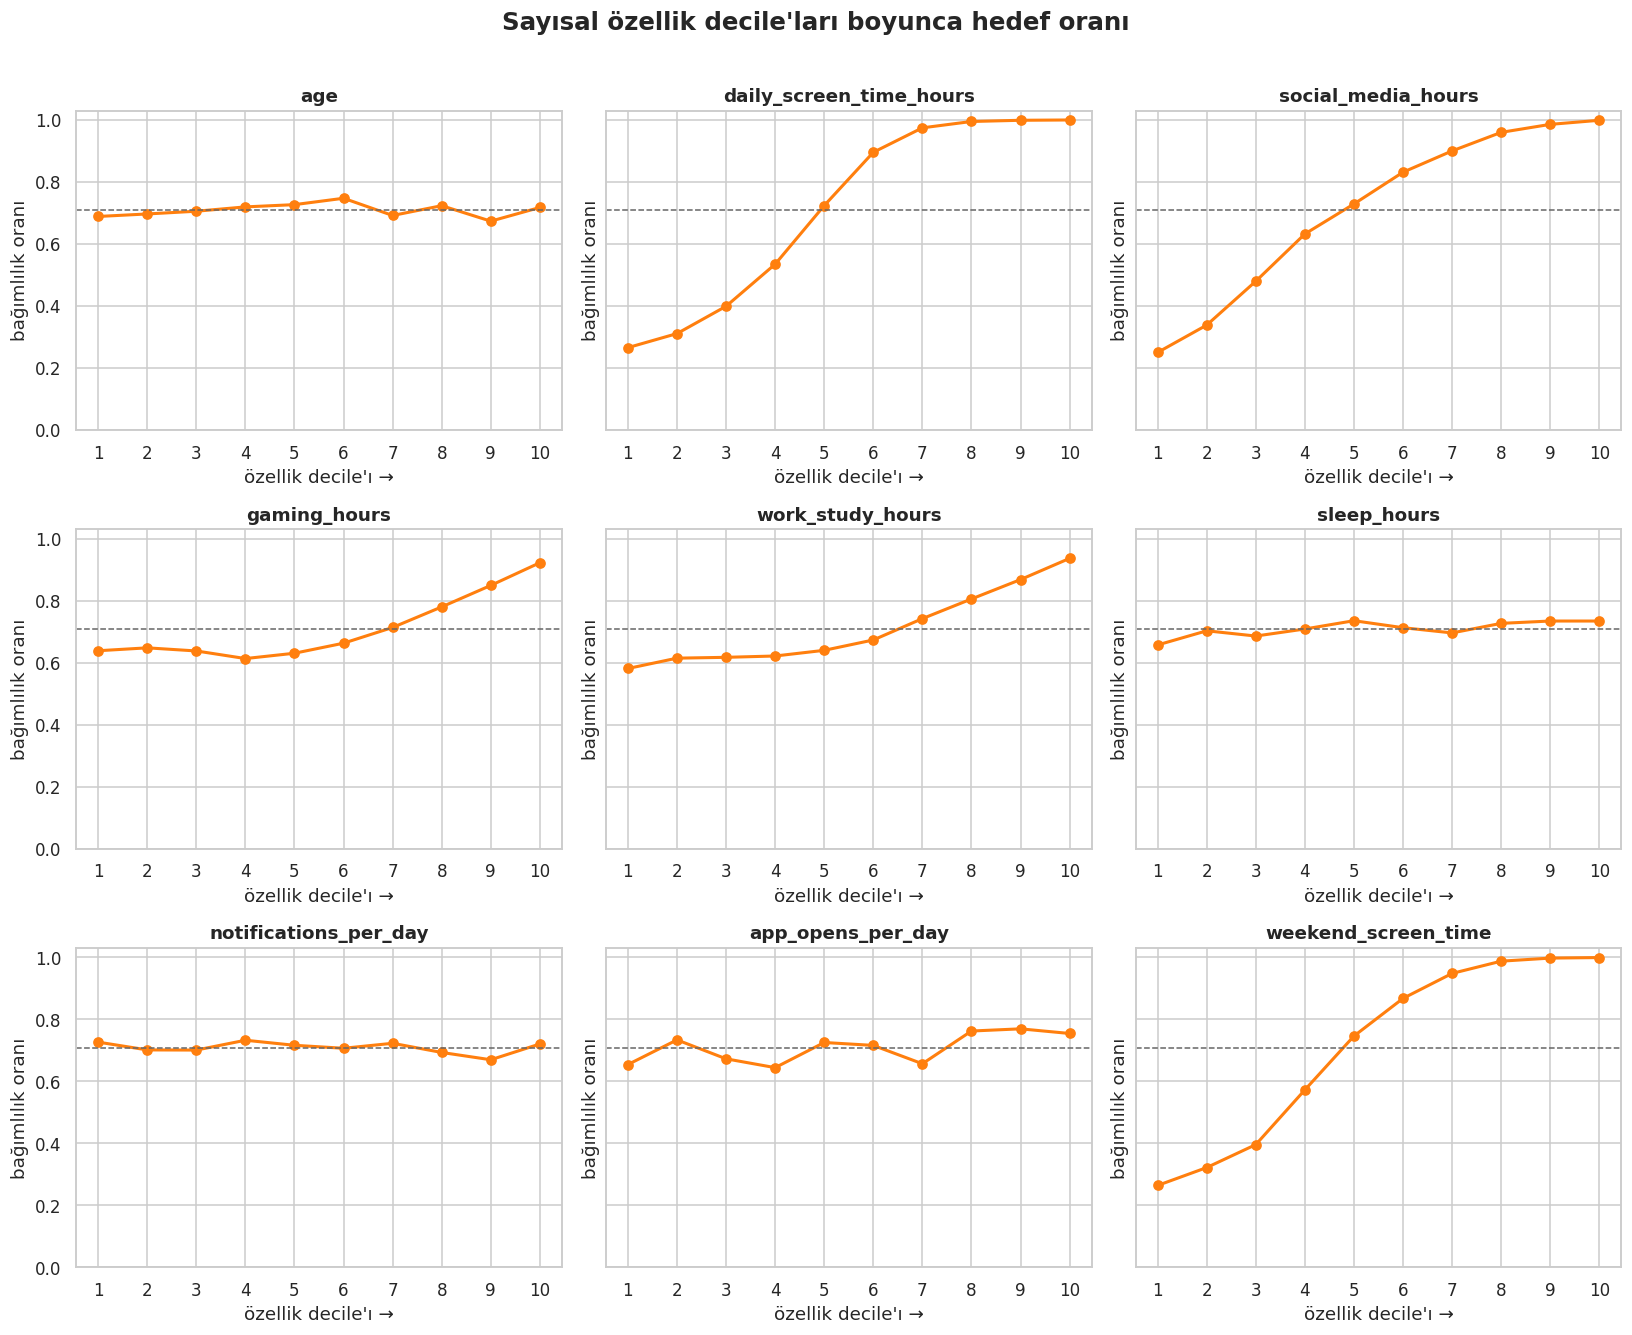

In [8]:
NUM_FEATURES = [c for c in FEATURES if pd.api.types.is_numeric_dtype(train[c])]

def decile_target_curve(df: pd.DataFrame, col: str, target: str = TARGET, q: int = 10):
    tmp = df[[col, target]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[col], q=q, labels=False, duplicates="drop")
    out = tmp.groupby("bin")[target].agg(["mean", "size"]).reset_index()
    out["decile"] = out["bin"] + 1
    return out

curve_summary = []
curves = {}
for col in NUM_FEATURES:
    g = decile_target_curve(train, col)
    curves[col] = g
    curve_summary.append({
        "feature": col,
        "min_rate": g["mean"].min(),
        "max_rate": g["mean"].max(),
        "range_pp": 100 * (g["mean"].max() - g["mean"].min()),
    })

curve_summary = pd.DataFrame(curve_summary).sort_values("range_pp", ascending=False)
display(curve_summary.style.format({
    "min_rate": "{:.3f}", "max_rate": "{:.3f}", "range_pp": "{:.1f} pp"
}).background_gradient(subset=["range_pp"], cmap="Oranges"))

n_wide = 3
n_rows = int(np.ceil(len(NUM_FEATURES) / n_wide))
fig, axes = plt.subplots(n_rows, n_wide, figsize=(15, 4.0 * n_rows), sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, NUM_FEATURES):
    g = curves[col]
    ax.plot(g["decile"], g["mean"], marker="o", linewidth=2, color=LINE_COLOR)
    ax.axhline(train[TARGET].mean(), color="0.4", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("özellik decile'ı →")
    ax.set_ylabel("bağımlılık oranı")
    ax.set_xticks(range(1, len(g) + 1))
    ax.set_ylim(0, 1.03)

for ax in axes[len(NUM_FEATURES):]:
    ax.axis("off")

fig.suptitle("Sayısal özellik decile'ları boyunca hedef oranı", y=1.01, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


8. Etkileşim Isı Haritaları (Heatmap) 🔥

Tek değişkenli grafikler sadece birinci bölüm. Şimdi iki özellik birlikte hareket ettiğinde hedefin farklı davranıp davranmadığını soralım.

Aşağıdaki hücreler, kantil (quantile) grup kombinasyonları için **ortalama `addicted_label`** değerini gösteriyor. Koyu/yüksek hücreler, daha yüksek bağımlılık oranına sahip kombinasyonlardır.


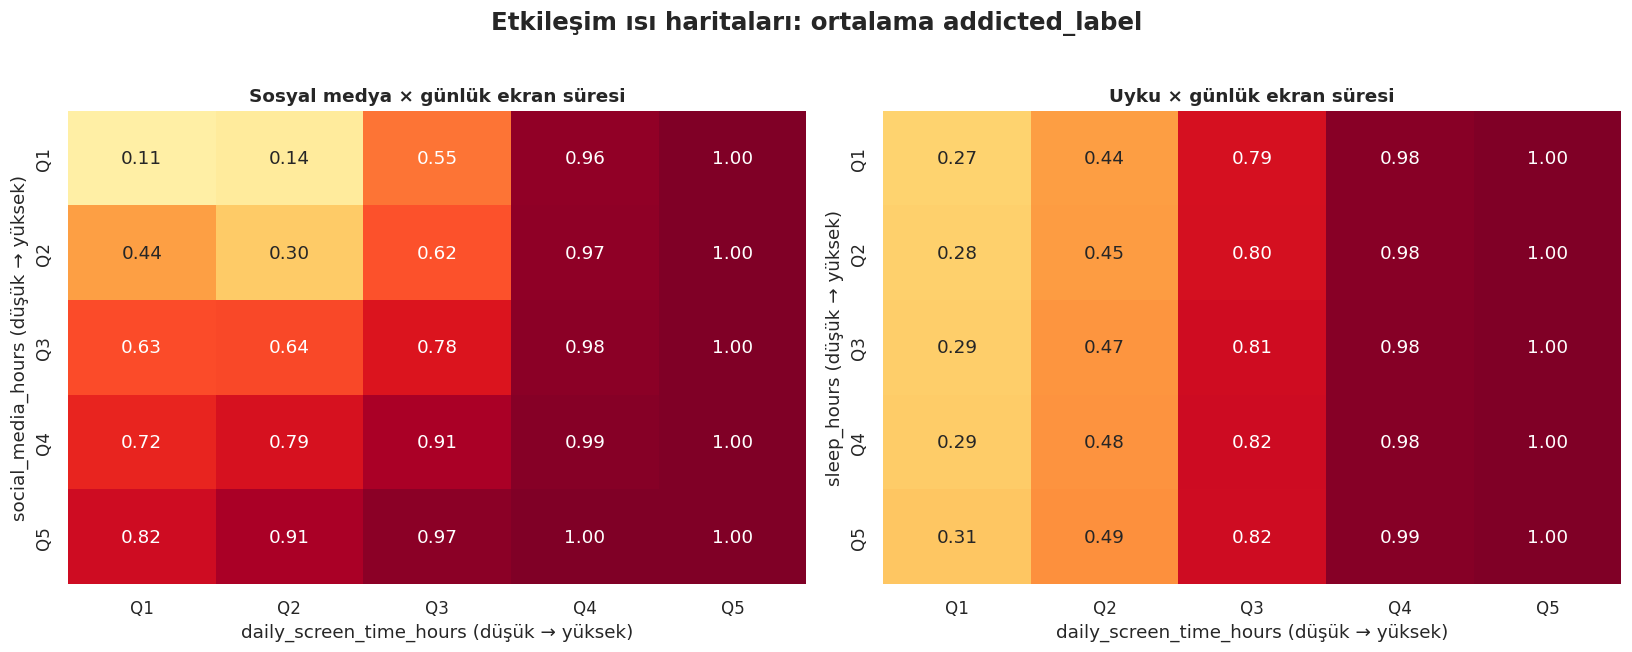

In [9]:
def qcut_labels(s: pd.Series, q: int = 5, prefix: str = "Q") -> pd.Series:
    out = pd.Series(index=s.index, dtype="object")
    valid = s.notna()
    bins = pd.qcut(s[valid], q=q, labels=False, duplicates="drop")
    out.loc[valid] = bins.map(lambda x: f"{prefix}{int(x)+1}")
    return out

def target_rate_heatmap(df, x, y, q=5, ax=None, title=None):
    tmp = df[[x, y, TARGET]].copy()
    tmp["x_bin"] = qcut_labels(tmp[x], q=q)
    tmp["y_bin"] = qcut_labels(tmp[y], q=q)
    pivot = tmp.groupby(["y_bin", "x_bin"], observed=True)[TARGET].mean().unstack()
    order = [f"Q{i}" for i in range(1, q + 1)]
    pivot = pivot.reindex(index=order, columns=order)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set_xlabel(f"{x} (düşük → yüksek)")
    ax.set_ylabel(f"{y} (düşük → yüksek)")
    ax.set_title(title or f"{y} × {x}")
    return pivot

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
target_rate_heatmap(
    train, "daily_screen_time_hours", "social_media_hours", q=5, ax=axes[0],
    title="Sosyal medya × günlük ekran süresi"
)
target_rate_heatmap(
    train, "daily_screen_time_hours", "sleep_hours", q=5, ax=axes[1],
    title="Uyku × günlük ekran süresi"
)
fig.suptitle("Etkileşim ısı haritaları: ortalama addicted_label", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


 9. Kategorik Kombinasyonlar: Küçük Değişkenler, Büyük Kişilik 🎲

Kategorik özelliklerin sadece birkaç seviyesi var, bu da onları tam (exact) etkileşim tabloları için mükemmel kılıyor. Bunlar en güçlü tek başına tahmin ediciler olmayabilir, ama ağaç tabanlı modeller bunları hâlâ değiştirici (modifier) olarak kullanabilir.


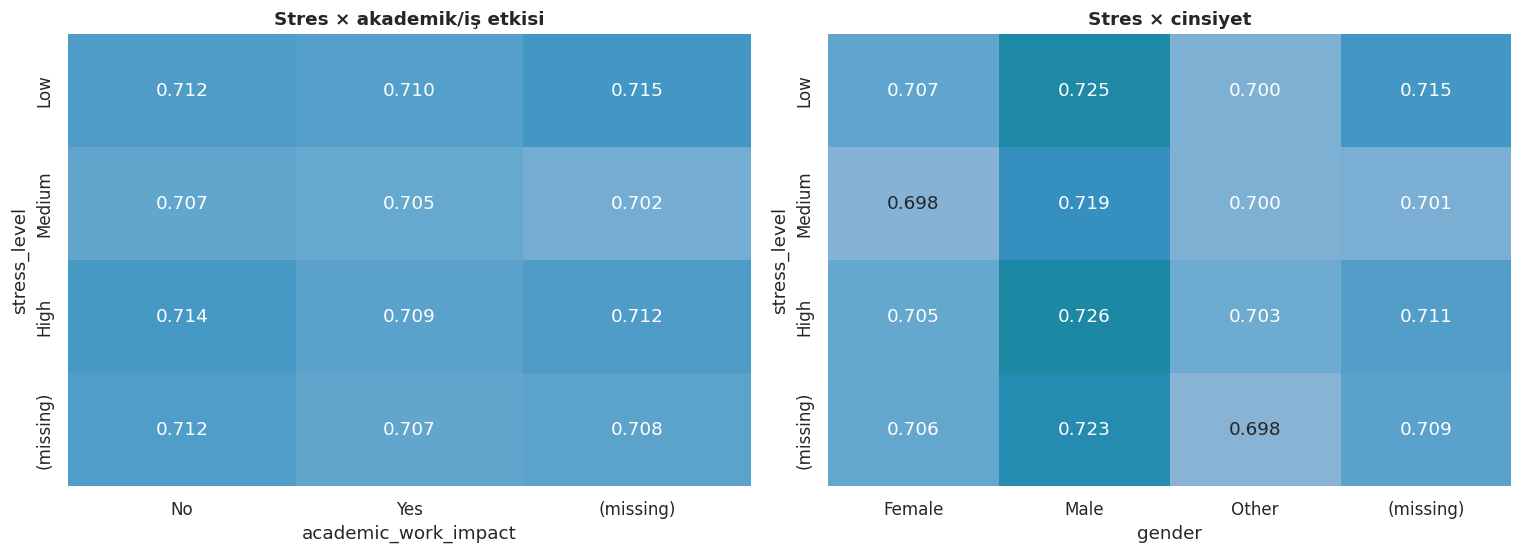

In [10]:
cat_df = train[["gender", "stress_level", "academic_work_impact", TARGET]].copy()
for c in ["gender", "stress_level", "academic_work_impact"]:
    cat_df[c] = cat_df[c].fillna("(missing)")

stress_order = ["Low", "Medium", "High", "(missing)"]
impact_order = ["No", "Yes", "(missing)"]
gender_order = ["Female", "Male", "Other", "(missing)"]

p1 = cat_df.pivot_table(index="stress_level", columns="academic_work_impact", values=TARGET, aggfunc="mean")
p1 = p1.reindex(index=stress_order, columns=impact_order)

p2 = cat_df.pivot_table(index="stress_level", columns="gender", values=TARGET, aggfunc="mean")
p2 = p2.reindex(index=stress_order, columns=gender_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.heatmap(p1, annot=True, fmt=".3f", cmap="PuBuGn", vmin=0.65, vmax=0.76, ax=axes[0], cbar=False)
axes[0].set_title("Stres × akademik/iş etkisi")
axes[0].set_xlabel("academic_work_impact")
axes[0].set_ylabel("stress_level")

sns.heatmap(p2, annot=True, fmt=".3f", cmap="PuBuGn", vmin=0.65, vmax=0.76, ax=axes[1], cbar=False)
axes[1].set_title("Stres × cinsiyet")
axes[1].set_xlabel("gender")
axes[1].set_ylabel("stress_level")

plt.tight_layout()
plt.show()


10. Feature Engineering Oyun Alanı 🧪

Şimdi eğlenceli kısma geldik: bir insanın doğal olarak düşünebileceği birkaç değişken üretelim.

Örnekler:
* **zaman muhasebesi artığı (residual)** = günlük ekran süresi − sosyal medya − oyun − iş/ders
* **hafta sonu artışı** = hafta sonu ekran süresi − günlük ekran süresi
* **sosyal pay** = sosyal medya saatleri / günlük ekran süresi
* **ekran saati başına açılış** = uygulama açılışları / günlük ekran süresi
* **uyku eksi ekran** = uyku saatleri − günlük ekran süresi

Bunlar bir modeli **kesinlikle** iyileştireceği garanti edilen değişkenler değil. Amaç, basit dönüşümlerin ham sütunlardan daha temiz, monoton bir yapı ortaya çıkarıp çıkarmadığını görmek.

,engineered_feature,missing_%,min_rate,max_rate,range_pp
6,sleep_minus_screen,19.1%,0.293,0.999,70.6 pp
1,time_accounting_residual,39.0%,0.423,0.970,54.7 pp
4,opens_per_screen_hour,23.4%,0.299,0.834,53.4 pp
3,gaming_share_of_daily,26.6%,0.426,0.784,35.8 pp
2,social_share_of_daily,27.4%,0.563,0.861,29.8 pp
5,notifications_per_open,17.8%,0.666,0.739,7.3 pp
0,weekend_lift,25.1%,0.684,0.741,5.7 pp


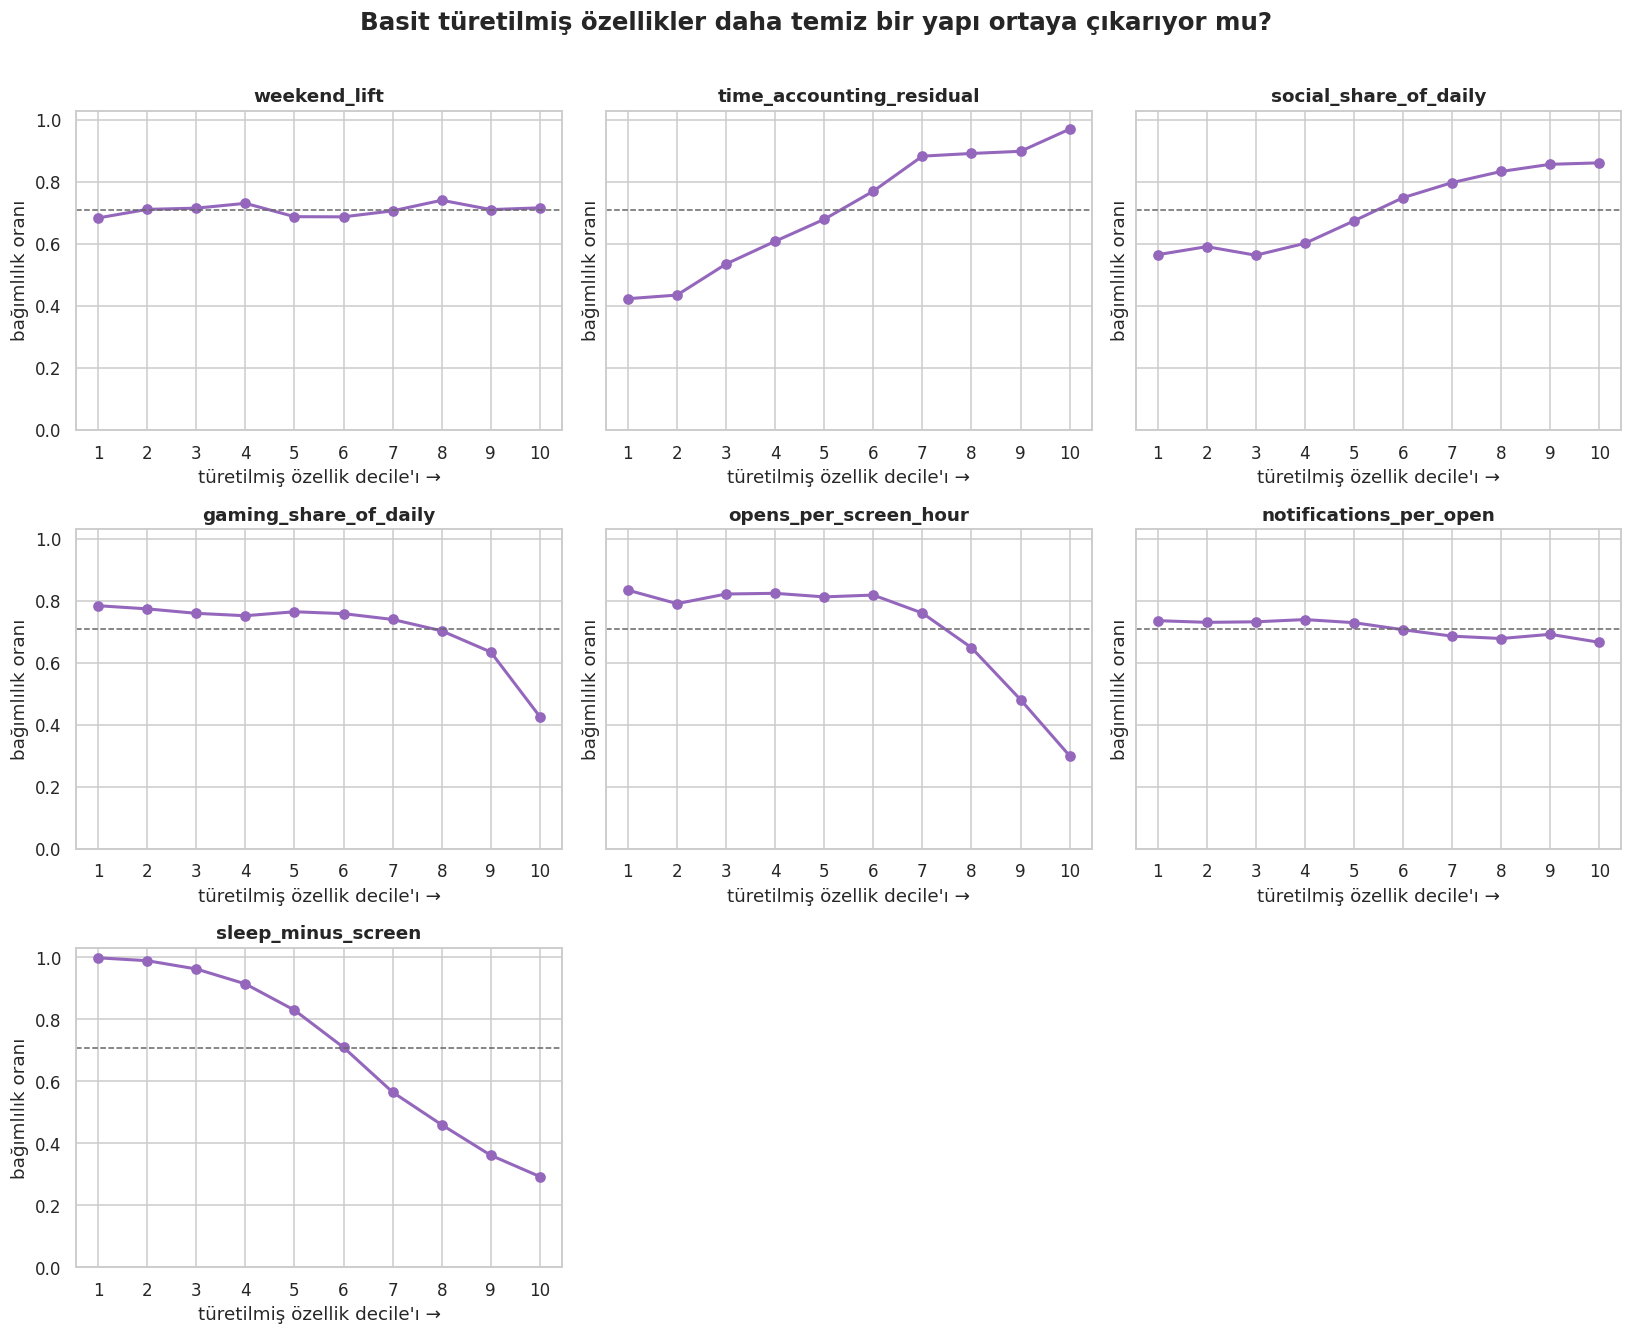

In [11]:
engineered = pd.DataFrame(index=train.index)
engineered["weekend_lift"] = train["weekend_screen_time"] - train["daily_screen_time_hours"]
engineered["time_accounting_residual"] = (
    train["daily_screen_time_hours"]
    - train["social_media_hours"]
    - train["gaming_hours"]
    - train["work_study_hours"]
)
engineered["social_share_of_daily"] = train["social_media_hours"] / train["daily_screen_time_hours"]
engineered["gaming_share_of_daily"] = train["gaming_hours"] / train["daily_screen_time_hours"]
engineered["opens_per_screen_hour"] = train["app_opens_per_day"] / train["daily_screen_time_hours"]
engineered["notifications_per_open"] = train["notifications_per_day"] / train["app_opens_per_day"]
engineered["sleep_minus_screen"] = train["sleep_hours"] - train["daily_screen_time_hours"]
engineered = engineered.replace([np.inf, -np.inf], np.nan)

eng_curves = {}
eng_summary = []
for col in engineered.columns:
    tmp = pd.DataFrame({col: engineered[col], TARGET: train[TARGET]})
    g = decile_target_curve(tmp, col)
    eng_curves[col] = g
    eng_summary.append({
        "engineered_feature": col,
        "missing_%": 100 * engineered[col].isna().mean(),
        "min_rate": g["mean"].min(),
        "max_rate": g["mean"].max(),
        "range_pp": 100 * (g["mean"].max() - g["mean"].min()),
    })

eng_summary = pd.DataFrame(eng_summary).sort_values("range_pp", ascending=False)
display(eng_summary.style.format({
    "missing_%": "{:.1f}%", "min_rate": "{:.3f}", "max_rate": "{:.3f}", "range_pp": "{:.1f} pp"
}).background_gradient(subset=["range_pp"], cmap="Purples"))

n_wide = 3
n_rows = int(np.ceil(len(eng_curves) / n_wide))
fig, axes = plt.subplots(n_rows, n_wide, figsize=(15, 4.0 * n_rows), sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax, (col, g) in zip(axes, eng_curves.items()):
    ax.plot(g["decile"], g["mean"], marker="o", linewidth=2, color=ACCENT_COLOR)
    ax.axhline(train[TARGET].mean(), color="0.4", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("türetilmiş özellik decile'ı →")
    ax.set_ylabel("bağımlılık oranı")
    ax.set_ylim(0, 1.03)
    ax.set_xticks(range(1, len(g) + 1))
for ax in axes[len(eng_curves):]:
    ax.axis("off")
fig.suptitle("Basit türetilmiş özellikler daha temiz bir yapı ortaya çıkarıyor mu?", y=1.01, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


11. ID Mantık Kontrolü 🧭

Sentetik tablosal yarışmalarda `id` genelde sadece bir satır tanımlayıcısıdır — ama veri üretim sürecinin satır sırasına göre değişip değişmediğini kontrol etmek yine de faydalıdır.

`id`'yi 20 eşit-frekanslı parçaya bölüyoruz ve şunları takip ediyoruz:
* hedef oranı
* satır başına ortalama eksik özellik sayısı

Düz (yatay) bir grafik, `id`'nin normal bir modelden çıkarılmasının muhtemelen güvenli olduğunu gösterir.


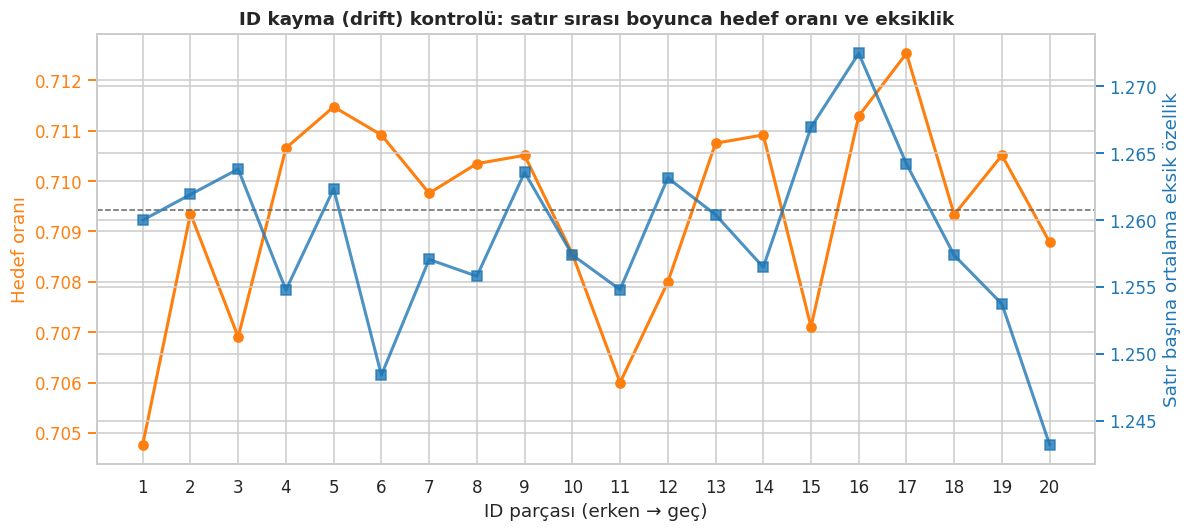

20 ID parçası boyunca hedef oranı aralığı: 0.777 yüzde puanı


In [12]:
id_check = train[[ID_COL, TARGET] + FEATURES].copy()
id_check["missing_count"] = id_check[FEATURES].isna().sum(axis=1)
id_check["id_bin"] = pd.qcut(id_check[ID_COL], q=20, labels=False, duplicates="drop") + 1

id_summary = id_check.groupby("id_bin").agg(
    target_rate=(TARGET, "mean"),
    avg_missing=("missing_count", "mean"),
    rows=(TARGET, "size"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(id_summary["id_bin"], id_summary["target_rate"], marker="o", color=LINE_COLOR, linewidth=2)
ax1.axhline(train[TARGET].mean(), color="0.4", linestyle="--", linewidth=1)
ax1.set_xlabel("ID parçası (erken → geç)")
ax1.set_ylabel("Hedef oranı", color=LINE_COLOR)
ax1.tick_params(axis="y", colors=LINE_COLOR)
ax1.set_xticks(id_summary["id_bin"])

ax2 = ax1.twinx()
ax2.plot(id_summary["id_bin"], id_summary["avg_missing"], marker="s", color=BAR_COLOR, linewidth=2, alpha=0.8)
ax2.set_ylabel("Satır başına ortalama eksik özellik", color=BAR_COLOR)
ax2.tick_params(axis="y", colors=BAR_COLOR)

ax1.set_title("ID kayma (drift) kontrolü: satır sırası boyunca hedef oranı ve eksiklik")
plt.tight_layout()
plt.show()

print(f"20 ID parçası boyunca hedef oranı aralığı: {100*(id_summary.target_rate.max()-id_summary.target_rate.min()):.3f} yüzde puanı")


12. Hızlı "Neyi Modellemeliyim?" Skor Tablosu 🏁

Bu bir **model liderlik tablosu değil**. Bu bir EDA skor tablosu: ham sayısal özellikleri, hedef oranlarının decile'lar arasında ne kadar değiştiğine göre sıralıyor, sonra bunu türetilmiş (engineered) özelliklerle karşılaştırıyor.

Büyük aralıklar (range), özelliğin güçlü doğrusal olmayan sinyal içerdiğine dair bir ipucudur. Küçük aralıklar bir özelliğin işe yaramaz olduğu anlamına **gelmez** — etkileşimler yine de önemli olabilir.


,name,range_pp,kind
0,social_media_hours,74.9 pp,ham sayısal
1,weekend_screen_time,73.5 pp,ham sayısal
2,daily_screen_time_hours,73.5 pp,ham sayısal
9,sleep_minus_screen,70.6 pp,türetilmiş
10,time_accounting_residual,54.7 pp,türetilmiş
11,opens_per_screen_hour,53.4 pp,türetilmiş
12,gaming_share_of_daily,35.8 pp,türetilmiş
3,work_study_hours,35.5 pp,ham sayısal
4,gaming_hours,30.9 pp,ham sayısal
13,social_share_of_daily,29.8 pp,türetilmiş


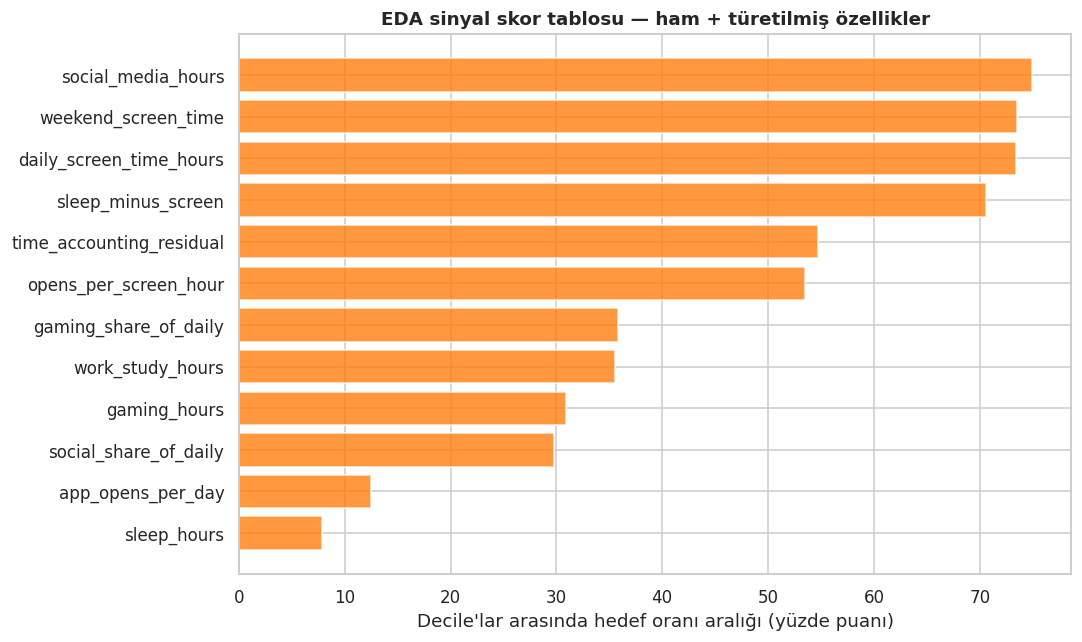

In [13]:
raw_board = curve_summary[["feature", "range_pp"]].rename(columns={"feature": "name"})
raw_board["kind"] = "ham sayısal"
eng_board = eng_summary[["engineered_feature", "range_pp"]].rename(columns={"engineered_feature": "name"})
eng_board["kind"] = "türetilmiş"
scoreboard = pd.concat([raw_board, eng_board], ignore_index=True).sort_values("range_pp", ascending=False)

display(scoreboard.head(15).style.format({"range_pp": "{:.1f} pp"}).background_gradient(subset=["range_pp"], cmap="YlOrRd"))

plot_board = scoreboard.head(12).sort_values("range_pp")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_board["name"], plot_board["range_pp"], alpha=0.8, color=LINE_COLOR)
ax.set_xlabel("Decile'lar arasında hedef oranı aralığı (yüzde puanı)")
ax.set_title("EDA sinyal skor tablosu — ham + türetilmiş özellikler")
plt.tight_layout()
plt.show()


13. Sonuçlar 🧠✨

Yukarıdaki EDA'dan, modellemeye şu fikirleri taşırdım:

* Veri setinde ekran süresiyle ilgili değişkenlerde **büyük, düzgün (smooth) doğrusal olmayan sinyal** var. `daily_screen_time_hours`, `weekend_screen_time` ve `social_media_hours` özellikle esnek şekilde modellenmesi gereken değişkenler.
* Eksik değerler her tahmin edicide yaygın, ama **eksikliğin kendisinin tek başına hedef üzerindeki etkisi küçük**. NaN'leri iyi işleyen bir model/imputation stratejisi kullanın; açık eksiklik bayrakları test etmesi kolay ama muhtemelen hikayenin tamamı değil.
* Birçok ham değişken, ekran süresi değişkenlerinden çok daha zayıf tek boyutlu sinyal gösteriyor, bu yüzden **özellik etkileşimleri muhtemelen önemli**.
* Basit, insan tarafından okunabilir dönüşümler — özellikle **zaman-tahsisi artıkları, oranlar ve ekran-uyku farkları** — güçlü hedef yapısı ortaya çıkarıyor ve cross-validation'da test edilmeye değer.
* Kategorik değişkenlerin tek başına etkileri mütevazı, ama dahil etmesi ucuz ve etkileşim değiştiricisi olarak yardımcı olabilirler.
* `id`, satır sırasına göre büyük ölçüde stabil görünüyor, bu yüzden cross-validation aksini kanıtlamadıkça öncelikle bir tanımlayıcı olarak ele alınmalı.

## İlk modelleme denemelerim şunlar olurdu:
1. Yerel veya açık eksik-değer işleme özellikli **CatBoost / LightGBM / XGBoost**.
2. **ROC AUC** ile skorlanan stratified cross-validation.
3. Ham özellikleri, yukarıdaki küçük türetilmiş özellik setiyle karşılaştırmak.
4. Açık `is_missing_*` göstergeleri eklemenin OOF AUC'a yardımcı olup olmadığını kontrol etmek.
5. Agresif feature engineering'e karar vermeden önce train/test drift'i incelemek.

Ve en önemlisi: **güzel bir EDA grafiğinden çok cross-validation'a güvenin.** 😄
